In [ ]:
!pip install gensim

In [145]:
import numpy as np
import matplotlib.pyplot as plt
import random
import nltk
import asyncio
from nltk.corpus import wordnet as wn
from collections import defaultdict
from googletrans import Translator
import gensim.downloader as api
from gensim.models import KeyedVectors
from sklearn.decomposition import PCA

nltk.download('wordnet')


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [35]:
def similaridade_cosseno(a, b):
    return np.dot(a, b)

In [4]:
def gerar_planos_aleatorios(n_planos, dim):

    planos = np.random.randn(n_planos, dim)

    planos = planos / np.linalg.norm(planos, axis=1, keepdims=True)

    return planos

In [5]:
gerar_planos_aleatorios(50, 100)

array([[-0.12710702,  0.12024033, -0.0193945 , ..., -0.12743062,
         0.07727279, -0.03075357],
       [-0.24069452, -0.04360748, -0.22235834, ...,  0.03729762,
        -0.14349008, -0.00377448],
       [ 0.05685865, -0.05426176, -0.01269442, ...,  0.0100656 ,
        -0.10619428,  0.13122384],
       ...,
       [ 0.00423118,  0.02406649, -0.17104381, ..., -0.03624722,
         0.08326102,  0.12083726],
       [-0.00782037,  0.11203161, -0.11071566, ...,  0.06326504,
         0.09195429,  0.07183158],
       [-0.05698439,  0.15418228, -0.04468738, ..., -0.00460907,
         0.14937213,  0.0227779 ]])

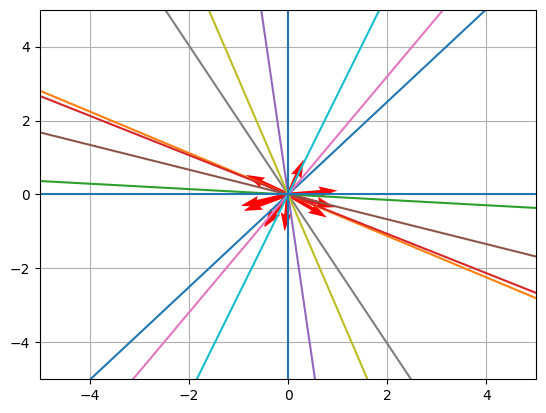

In [6]:
r = gerar_planos_aleatorios(10, 2)

x = np.linspace(-5, 5, 200)

plt.figure()

for i, r_vec in enumerate(r):

    if abs(r_vec[1]) < 1e-6:
        plt.axvline(0)
    else:
        y = -(r_vec[0] / r_vec[1]) * x
        plt.plot(x, y)

    plt.quiver(0, 0, r_vec[0], r_vec[1],
               angles='xy', scale_units='xy', scale=1,
               color='red')

plt.xlim(-5, 5)
plt.ylim(-5, 5)
plt.axhline(0)
plt.axvline(0)
plt.grid()
plt.show()

In [7]:
def lado_plano(plano, vetor):
    return np.dot(plano, vetor)
def calcular_valor_hash(planos,vetor):
  valor_hash = 0
  valores_hash = []

  for i, P in enumerate(planos):
    sinal = lado_plano(P,vetor)
    hash_i = 1 if sinal >= 0 else 0
    valores_hash.append(2 ** i * hash_i)
    valor_hash += valores_hash[i]
  return valor_hash, valores_hash

In [8]:
r = gerar_planos_aleatorios(10, 2)

calcular_valor_hash(r, np.array([1,1]))

(128, [0, 0, 0, 0, 0, 0, 0, 128, 0, 0])

In [9]:
r = gerar_planos_aleatorios(10, 3)

calcular_valor_hash(r, np.array([1,1,5]))

(386, [0, 2, 0, 0, 0, 0, 0, 128, 256, 0])

## Tradutor Russo para Inglês

A tradução automática de textos sempre foi um dos grandes objetivos da pesquisa em inteligência artificial, especialmente no contexto da Guerra Fria, quando havia forte interesse em traduzir rapidamente publicações científicas soviéticas. No entanto, as limitações computacionais e teóricas da época fizeram com que esse objetivo parecesse, por décadas, praticamente inalcançável.
Isso foi somente se tornar totalmente viável algumas décadas atrás, com o desenvolvimento de técnicas de backpropagation, redes neurais profundas, e NLP em geral, especialmente em 2016 com a criação dos Transformers.

Portanto, atualmente essa tarefa pode ser feita com certa facilidade. A utilização de locale sensitive hashing com planos aleatórios para criação de "baldes" e um KNN aproximado sob vizinhos do mesmo balde pode possibilitar a criação de um tradutor rudimentar de inglês para russo e vice-versa.

### Palavras aleatórias

Podemos começar pegando 5000 palavras aleatórias do inglês e suas traduções para russo, assim pegando seus respectivos embeddings de cada linguagem. É importante ter uma boa base de exemplos pois as linguagens são vastas e embeddings de palavra assumem diversas representações distintas.
5000 palavras já possibilita a criação de um modelo capaz de aprender uma matriz de transformação.
É utilizado vetores do **FastText** de todas as palavras em inglês e russo, em seguida é pego os embeddings das 200.000 primeiras palavras, pois os arquivos são muito pesados. Em seguida 5000 das palavras são pegas para formar um dicionário com os embeddings em inglês e russo.

In [13]:
!wget -O wiki.en.align.vec https://dl.fbaipublicfiles.com/fasttext/vectors-aligned/wiki.en.align.vec
!wget -O wiki.ru.align.vec https://dl.fbaipublicfiles.com/fasttext/vectors-aligned/wiki.ru.align.vec
!wget -O en-ru.0-5000.txt https://dl.fbaipublicfiles.com/arrival/dictionaries/en-ru.0-5000.txt

--2026-02-26 13:17:11--  https://dl.fbaipublicfiles.com/fasttext/vectors-aligned/wiki.en.align.vec
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 3.167.56.37, 3.167.56.129, 3.167.56.119, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|3.167.56.37|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 5685446378 (5.3G) [binary/octet-stream]
Saving to: ‘wiki.en.align.vec’

wiki.en.align.vec   100%[===================>]   5.29G  49.2MB/s    in 2m 6s   

2026-02-26 13:19:17 (43.1 MB/s) - ‘wiki.en.align.vec’ saved [5685446378/5685446378]

--2026-02-26 13:19:17--  https://dl.fbaipublicfiles.com/fasttext/vectors-aligned/wiki.ru.align.vec
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 54.230.79.122, 54.230.79.93, 54.230.79.88, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|54.230.79.122|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4284700660 (4.0G) [binary/octet-stream]
Saving to: ‘

In [18]:
def gerar_dicionario_embeddings_palavras_aleatorias(
    n=5000,
    dict_path="en-ru.0-5000.txt",
    en_vec_path="wiki.en.align.vec",
    ru_vec_path="wiki.ru.align.vec",
    seed=11
):
    random.seed(seed)
    print("Carregando dicts")
    emb_en = KeyedVectors.load_word2vec_format(en_vec_path, binary=False,limit=200000)
    emb_ru = KeyedVectors.load_word2vec_format(ru_vec_path, binary=False,limit=200000)
    print("Lendo")
    pares_validos = []
    with open(dict_path, "r", encoding="utf-8") as f:
        for linha in f:
            parts = linha.strip().split()
            if len(parts) != 2:
                continue
            en, ru = parts
            if en in emb_en and ru in emb_ru:
                pares_validos.append((en, ru))

    if not pares_validos:
        return {}

    random.shuffle(pares_validos)
    pares_validos = pares_validos[:min(n, len(pares_validos))]

    dicionario = {}
    for en, ru in pares_validos:
        dicionario[en] = {
            "ru_word": ru,
            "embedding_en": emb_en[en],
            "embedding_ru": emb_ru[ru],
        }

    print(f"Pares válidos carregados: {len(pares_validos)}")
    return dicionario

In [19]:
dicionario_palavras_aleatorias =gerar_dicionario_embeddings_palavras_aleatorias(n=5000)

Carregando dicts
Lendo
Pares válidos carregados: 5000


In [27]:
dicionario_palavras_aleatorias["hello"]["embedding_en"]

array([-0.0376, -0.0431,  0.0079,  0.0444, -0.016 , -0.0323, -0.0603,
        0.026 ,  0.0408,  0.0123, -0.0055,  0.0092, -0.0579, -0.051 ,
        0.0848, -0.0195,  0.0287, -0.0632,  0.0238, -0.0322, -0.0219,
        0.1224,  0.0419,  0.0224, -0.0436, -0.0101,  0.0033,  0.0397,
       -0.0438,  0.0083, -0.0243,  0.0424, -0.0125,  0.017 , -0.1008,
       -0.0274, -0.0022,  0.0335, -0.0538, -0.0041,  0.0195, -0.1051,
       -0.0179, -0.034 , -0.0195,  0.0475, -0.0225, -0.0261, -0.1105,
        0.0481, -0.0405, -0.1177,  0.0684, -0.0243,  0.0481,  0.1251,
       -0.06  , -0.1225,  0.0707,  0.0423,  0.0724,  0.061 , -0.0429,
       -0.0241, -0.027 , -0.0385, -0.0293,  0.0775, -0.0545,  0.0423,
        0.0234,  0.0439,  0.0661,  0.0433, -0.0411,  0.0629, -0.0043,
        0.067 ,  0.0409,  0.0688,  0.0194,  0.0438, -0.0367,  0.055 ,
        0.0864, -0.0727, -0.0376,  0.0953,  0.0362, -0.0275,  0.033 ,
        0.0152,  0.0521,  0.0195,  0.0302, -0.0158, -0.0054, -0.0454,
       -0.0129,  0.0

Como são embeddings de 300 dimensões, são gerados 10 planos aleatórios de 300 dimensões cada

In [57]:
hiperplanos_aleatorios = gerar_planos_aleatorios(10, 300)

In [58]:
calcular_valor_hash(hiperplanos_aleatorios,dicionario_palavras_aleatorias["hello"]["embedding_en"])

(965, [1, 0, 4, 0, 0, 0, 64, 128, 256, 512])

### Aprendizado da Matriz de Transformação

Queremos aprender uma matriz 𝑊 tal que:
$$
XW≈Y
$$

Ou seja, uma matriz de transformação que melhor aproxima X de Y.

Um método muito utilizado é o de Procrustes, que assume somente transformações de rotação, ou seja, restringe as possíveis transformações, de forma que:

$$
W=argmin∣∣XW−Y∣∣
$$

Onde é aprendido a matriz:

$$
M = X^{\top} Y
$$

Depois, é feito o SVD:

$$
UΣV^{\top}=SVD(M)
$$

A matriz ótima, por fim é:

$$
W=UV^{\top}
$$

#### Geração de dados de treino e teste

São gerados as matrizes X e Y com os embeddings em inglês e russo

In [75]:
def construir_XY(dicionario):
    pares = list(dicionario.items())

    palavras_en = [w for w, _ in pares]
    palavras_ru = [info["ru_word"] for _, info in pares]

    X = np.stack([info["embedding_en"] for _, info in pares]).astype(np.float32)
    Y = np.stack([info["embedding_ru"] for _, info in pares]).astype(np.float32)

    return X, Y, palavras_en, palavras_ru

X, Y, palavras_en, palavras_ru = construir_XY(dicionario_palavras_aleatorias)

#### Algoritmo Procrustes

O algoritmo de Procrustes é utilizado a seguir, onde ocorre uma centralização e normalização e depois o uso do SVD

In [76]:
def procrustes_ortogonal(X, Y, centralizar=True, normalizar=True):
    Xc = X.copy()
    Yc = Y.copy()

    if centralizar:
        Xc = Xc - Xc.mean(axis=0, keepdims=True)
        Yc = Yc - Yc.mean(axis=0, keepdims=True)

    if normalizar:
        Xc = Xc / (np.linalg.norm(Xc, axis=1, keepdims=True) + 1e-9)
        Yc = Yc / (np.linalg.norm(Yc, axis=1, keepdims=True) + 1e-9)

    M = Xc.T @ Yc
    U, _, Vt = np.linalg.svd(M, full_matrices=False)
    W = U @ Vt

    return W

W = procrustes_ortogonal(X, Y)


In [77]:
def mapear_en_para_ru(v_en, W):
    return v_en @ W

In [122]:
def aproximate_knn_busca(v_query, Y_norm, planos_lista, tabelas, topk=10):
    vq = v_query / (np.linalg.norm(v_query) + 1e-9)

    candidatos = set()

    for planos, tabela in zip(planos_lista, tabelas):
        h, _ = calcular_valor_hash(planos, vq)
        for idx in tabela.get(h, []):
            candidatos.add(idx)

    if not candidatos:
        return []

    cand = np.array(list(candidatos), dtype=int)
    scores = Y_norm[cand] @ vq

    ordem = np.argsort(scores)[-topk:][::-1]
    return [(int(cand[i]), float(scores[i])) for i in ordem]

#### Construindo Tabelas Hash

Com a função de cálculo de valor hash podemos construir as tabelas completas para os vetores atuais das palavras. Usaremos 50 tabelas com 10 dimensões cada

In [128]:
def construir_tabela_hash(planos, vetores, ids=None):
    tabela = defaultdict(list)
    if ids is None:
        ids = list(range(len(vetores)))

    for idx, v in zip(ids, vetores):
        h, _ = calcular_valor_hash(planos, v)
        tabela[h].append(idx)
    return tabela

def construir_multitabelas(Y, k=12, L=30):

    Y_norm = Y / (np.linalg.norm(Y, axis=1, keepdims=True) + 1e-9)

    planos_lista = []
    tabelas = []

    for t in range(L):
        planos = gerar_planos_aleatorios(k, Y_norm.shape[1])
        tabela = construir_tabela_hash(planos, Y_norm)
        planos_lista.append(planos)
        tabelas.append(tabela)

    return Y_norm, planos_lista, tabelas

In [129]:
Y_norm, planos_lista, tabelas = construir_multitabelas(Y, k=10, L=30)


#### Teste com "hello"

In [83]:
en_word = "hello"
ru_word = dicionario_palavras_aleatorias[en_word]["ru_word"]

v_en = dicionario_palavras_aleatorias[en_word]["embedding_en"]
v_ru_real = dicionario_palavras_aleatorias[en_word]["embedding_ru"]

v_ru_pred = mapear_en_para_ru(v_en, W)

similaridade_cosseno_teste = similaridade_cosseno(v_ru_pred, v_ru_real)
print("EN:", en_word, "\nRU real:", ru_word)
print("cos(pred, real) =", similaridade_cosseno_teste)

EN: hello 
RU real: здравствуйте
cos(pred, real) = 0.50425357


In [133]:
resultados = aproximate_knn_busca(v_ru_pred, Y_norm, planos_lista, tabelas, topk=10)
for idx, score in resultados:
    print(palavras_ru[idx], score)

спасибо 0.3918469548225403
ждём 0.3399883508682251
угадай 0.33093512058258057
подсказка 0.3225979208946228
ваши 0.31876808404922485
смешная 0.29403623938560486
начинайте 0.2892110049724579
пиши 0.28422263264656067
this 0.28157633543014526
возьмите 0.27993249893188477


In [134]:
for idx, score in resultados:
    print(palavras_ru[idx], score)

спасибо 0.3918469548225403
ждём 0.3399883508682251
угадай 0.33093512058258057
подсказка 0.3225979208946228
ваши 0.31876808404922485
смешная 0.29403623938560486
начинайте 0.2892110049724579
пиши 0.28422263264656067
this 0.28157633543014526
возьмите 0.27993249893188477


In [135]:
def normalizar(v):
    return v / (np.linalg.norm(v) + 1e-9)


def traduzir_palavra(palavra_ingles):

    ru_word = dicionario_palavras_aleatorias[palavra_ingles]["ru_word"]

    v_en = dicionario_palavras_aleatorias[palavra_ingles]["embedding_en"]
    v_ru_real = dicionario_palavras_aleatorias[palavra_ingles]["embedding_ru"]

    v_ru_pred = mapear_en_para_ru(v_en, W)

    v_ru_pred = normalizar(v_ru_pred)

    similaridade_cosseno_teste = similaridade_cosseno(v_ru_pred, normalizar(v_ru_real))

    print("Tradução real:", ru_word)
    print("Similaridade com real:", similaridade_cosseno_teste)

    resultados = aproximate_knn_busca(v_ru_pred, Y_norm, planos_lista, tabelas, topk=10)

    for idx, score in resultados:
        print(palavras_ru[idx], score)

In [136]:
def achar_maiores_similaridades(dicionario, W, topk=10):

    resultados = []

    for en, info in dicionario.items():

        v_en = info["embedding_en"]
        v_ru_real = info["embedding_ru"]

        v_ru_pred = v_en @ W

        v_ru_pred = v_ru_pred / (np.linalg.norm(v_ru_pred) + 1e-9)
        v_ru_real = v_ru_real / (np.linalg.norm(v_ru_real) + 1e-9)

        score = float(np.dot(v_ru_pred, v_ru_real))

        resultados.append((en, info["ru_word"], score))

    resultados.sort(key=lambda x: x[2], reverse=True)

    return resultados[:topk]

No caso de abril, por exemplo, a primeira palavra encontrada bate justamente com a tradução, mostrando que o modelo aprendeu essa palavra

In [137]:
traduzir_palavra("april")

Tradução real: апреля
Similaridade com real: 0.80576706
апреля 0.8057669997215271
июня 0.7801921367645264
сентября 0.7783892154693604
августа 0.7678929567337036
февраль 0.6531329154968262
февраль 0.6531329154968262
ноябрь 0.64179927110672
март 0.639910101890564
январь 0.6243894100189209
октябрь 0.620231568813324


Pode ver que mesmo quando a tradução não é correta, as primeiras palavra товаров (produto e pesca) se assemelha com a real, mostrando que de certa forma o modelo aprendeu similaridades

In [139]:
traduzir_palavra("food")

Tradução real: питание
Similaridade com real: 0.47096628
товаров 0.4064008593559265
рыболовство 0.3792175054550171
чая 0.36568933725357056
рестораны 0.3560551106929779
семена 0.34739255905151367
насекомыми 0.3458477556705475
подарки 0.3338187634944916
промышленность 0.3329017758369446
семян 0.3255639672279358
скот 0.3149524927139282


O modelo aprendeu também a palavra "maçã" e também associou à palavras como "fresco" e "sabor"

In [144]:
traduzir_palavra("apple")

Tradução real: яблочный
Similaridade com real: 0.48380804
яблочный 0.4838080406188965
свежий 0.31462955474853516
вкус 0.3036634624004364
software 0.2932211458683014
сервис 0.2914252281188965
inc 0.2736033797264099
лейк 0.2557767927646637
стек 0.25465425848960876
производительность 0.25276485085487366
вред 0.2523246705532074


In [138]:
top10 = achar_maiores_similaridades(dicionario_palavras_aleatorias, W, topk=10)

for en, ru, score in top10:
    print(f"{en} | {ru} | similaridade: {score:.4f}")

april | апреля | similaridade: 0.8058
september | сентября | similaridade: 0.7989
six | шесть | similaridade: 0.7875
august | августа | similaridade: 0.7810
june | июня | similaridade: 0.7746
nine | девять | similaridade: 0.7730
often | часто | similaridade: 0.7646
but | но | similaridade: 0.7617
virtually | практически | similaridade: 0.7561
concerts | концерты | similaridade: 0.7560


#### Mapeando top palavras com PCA

Para fins de visualização, podemos usar o PCA para visualizar como o modelo está mapeando seus embeddings e também a forma como palavras similares top-k se associam diretamente à palavra original mesmo não sendo a tradução literal

In [167]:
def traduzir_palavra_pca_2d(palavra_ingles):

    ru_word = dicionario_palavras_aleatorias[palavra_ingles]["ru_word"]

    v_en = dicionario_palavras_aleatorias[palavra_ingles]["embedding_en"]
    v_ru_real = dicionario_palavras_aleatorias[palavra_ingles]["embedding_ru"]

    v_ru_pred = mapear_en_para_ru(v_en, W)
    v_ru_pred = normalizar(v_ru_pred)
    v_ru_real = normalizar(v_ru_real)

    print("Tradução real:", ru_word)
    print("Similaridade com real:", similaridade_cosseno(v_ru_pred, v_ru_real))

    resultados = aproximate_knn_busca(v_ru_pred, Y_norm, planos_lista, tabelas, topk=10)

    vetores = []
    labels = []

    for idx, score in resultados:
        vetores.append(Y_norm[idx])
        labels.append(palavras_en[idx])

    vetores = np.array(vetores)

    pca = PCA(n_components=2)
    vetores_2d = pca.fit_transform(vetores)

    plt.figure(figsize=(8,8))

    for i, (x, y) in enumerate(vetores_2d):
        plt.scatter(x, y, alpha=0.6)
        if(labels[i] == palavra_ingles):
          plt.text(x+0.01, y+0.01, labels[i], fontsize=9,fontweight='bold')
        else:
          plt.text(x+0.01, y+0.01, labels[i], fontsize=9)

    plt.title(f"PCA 2D - Tradução de '{palavra_ingles}'")
    plt.grid(True)
    plt.show()

Tradução real: яблочный
Similaridade com real: 0.48380804


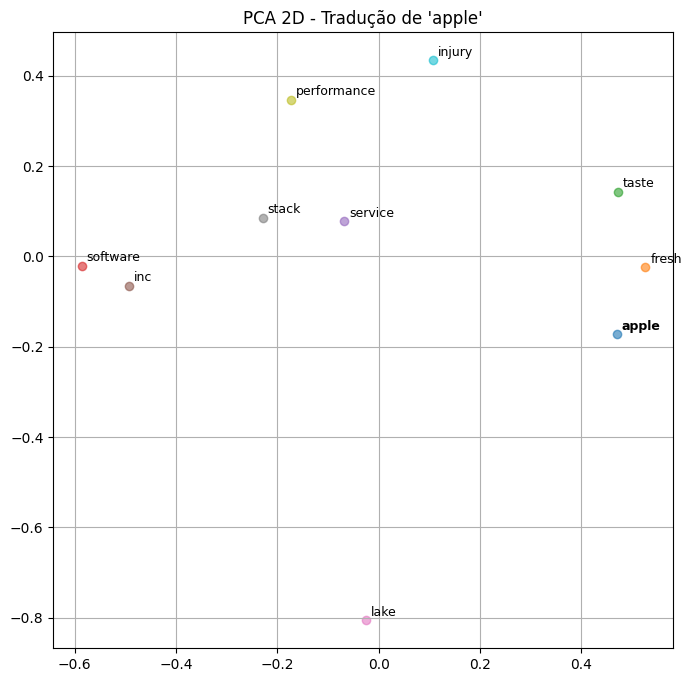

In [168]:
traduzir_palavra_pca_2d("apple")

Tradução real: апреля
Similaridade com real: 0.80576706


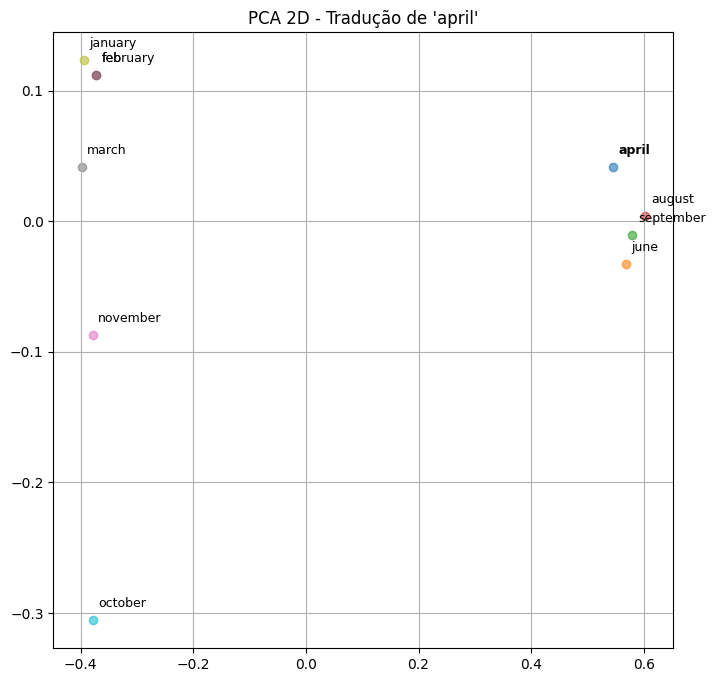

In [169]:
traduzir_palavra_pca_2d("april")

Note que o modelo aprendeu que embeddings dos meses ficam próximos, por isso os top 10 vizinhos próximos são os meses do ano

Tradução real: питание
Similaridade com real: 0.47096628


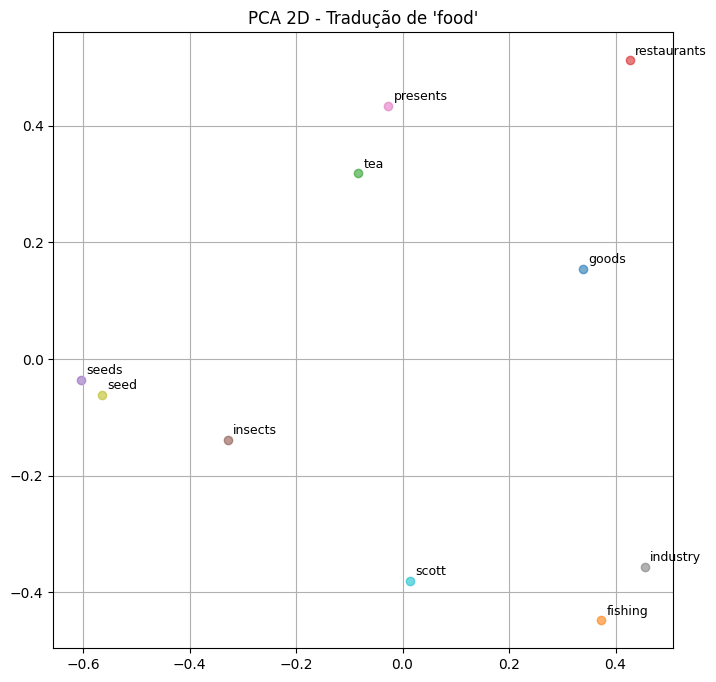

In [175]:
traduzir_palavra_pca_2d("food")

Pode notar também que para "food" certas palavras aparecem associadas, como "fishing", "seeds", "tea" e "restaurant" todas lembrando de certa forma comida.

Tradução real: ночное
Similaridade com real: 0.59000254


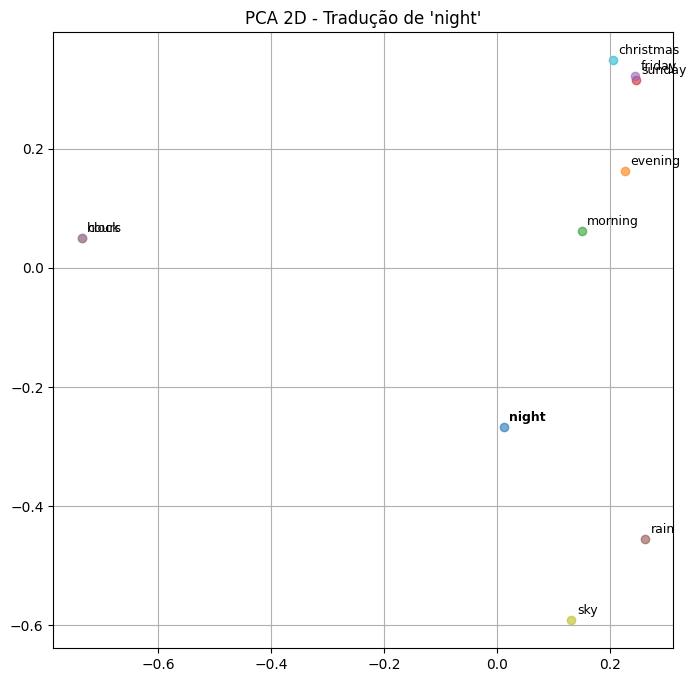

In [184]:
traduzir_palavra_pca_2d("night")

Noite é associada também há certas palavras como outros períodos do dia como "morning" e "evening".

Tradução real: пес
Similaridade com real: 0.5448752


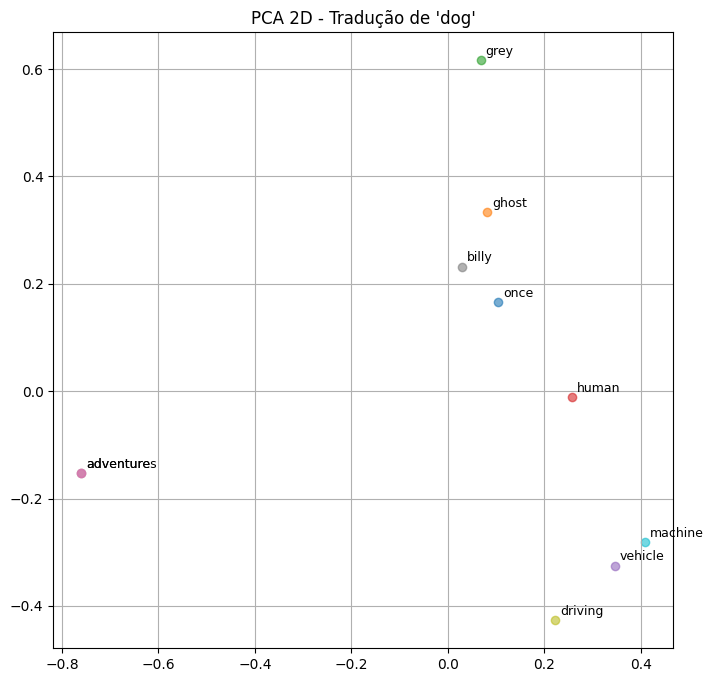

In [183]:
traduzir_palavra_pca_2d("dog")

Cachorro está associado à humanos e aventuras